# 01 数据探索分析（EDA）
从 CSV 文件读取数据，分析用户行为分布、商品热度、稀疏度等关键指标

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'SimHei'
matplotlib.rcParams['axes.unicode_minus'] = False

DATA_DIR = '../data/csv/'
products  = pd.read_csv(DATA_DIR + 'products.csv')
users     = pd.read_csv(DATA_DIR + 'users.csv')
behaviors = pd.read_csv(DATA_DIR + 'behaviors.csv', parse_dates=['created_at'])

print(f'商品数: {len(products)}, 用户数: {len(users)}, 行为数: {len(behaviors)}')

商品数: 496, 用户数: 206, 行为数: 19842


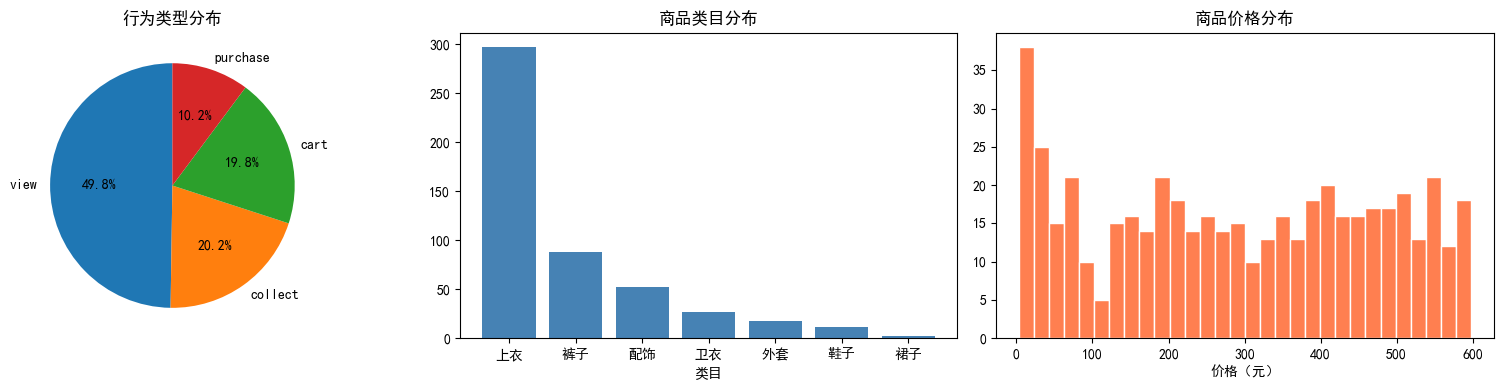

In [2]:
# 1. 行为类型分布
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 行为类型占比
act_counts = behaviors['action_type'].value_counts()
axes[0].pie(act_counts.values, labels=act_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('行为类型分布')

# 商品类目分布
cat_counts = products['category'].value_counts()
axes[1].bar(cat_counts.index, cat_counts.values, color='steelblue')
axes[1].set_title('商品类目分布')
axes[1].set_xlabel('类目')

# 价格分布
axes[2].hist(products['price'], bins=30, color='coral', edgecolor='white')
axes[2].set_title('商品价格分布')
axes[2].set_xlabel('价格（元）')

plt.tight_layout()
plt.savefig('../data/csv/eda_distribution.png', dpi=150)
plt.show()

In [3]:
# 2. 用户-商品矩阵稀疏度
n_users    = behaviors['user_id'].nunique()
n_products = behaviors['product_id'].nunique()
n_pairs    = behaviors.drop_duplicates(['user_id','product_id']).shape[0]
sparsity   = 1 - n_pairs / (n_users * n_products)

print(f'交互用户数 : {n_users}')
print(f'交互商品数 : {n_products}')
print(f'用户-商品对: {n_pairs}')
print(f'矩阵稀疏度 : {sparsity:.4%}')

交互用户数 : 206
交互商品数 : 496
用户-商品对: 18080
矩阵稀疏度 : 82.3050%


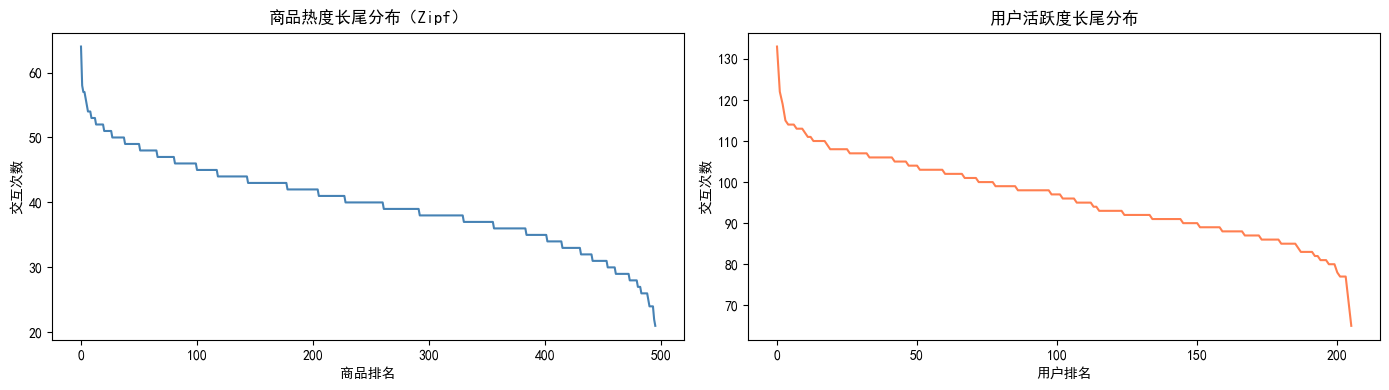

In [4]:
# 3. 热度长尾分布（Power Law）
prod_heat = behaviors.groupby('product_id').size().sort_values(ascending=False).reset_index()
prod_heat.columns = ['product_id', 'interaction_count']

user_active = behaviors.groupby('user_id').size().sort_values(ascending=False).reset_index()
user_active.columns = ['user_id', 'interaction_count']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(range(len(prod_heat)), prod_heat['interaction_count'], color='steelblue')
axes[0].set_title('商品热度长尾分布（Zipf）')
axes[0].set_xlabel('商品排名'); axes[0].set_ylabel('交互次数')

axes[1].plot(range(len(user_active)), user_active['interaction_count'], color='coral')
axes[1].set_title('用户活跃度长尾分布')
axes[1].set_xlabel('用户排名'); axes[1].set_ylabel('交互次数')

plt.tight_layout()
plt.savefig('../data/csv/eda_longtail.png', dpi=150)
plt.show()

In [5]:
# 4. 构建行为权重评分矩阵
WEIGHT = {'view': 1, 'collect': 3, 'cart': 5, 'purchase': 10}
behaviors['weight'] = behaviors['action_type'].map(WEIGHT)

rating_df = (behaviors.groupby(['user_id','product_id'])['weight']
             .sum().reset_index().rename(columns={'weight': 'rating'}))

# 归一化到 [1, 5]
max_r = rating_df['rating'].max()
rating_df['rating'] = (rating_df['rating'] / max_r * 4 + 1).clip(1, 5).round(2)

rating_df.to_csv('../data/csv/ratings.csv', index=False)
print(f'评分矩阵: {rating_df.shape}')
print(rating_df.describe())

评分矩阵: (18080, 3)
            user_id    product_id        rating
count  18080.000000  18080.000000  18080.000000
mean     105.073617   1252.500387      1.592538
std       59.640625    143.383479      0.538991
min        2.000000   1003.000000      1.170000
25%       54.000000   1128.000000      1.170000
50%      105.000000   1255.000000      1.520000
75%      157.000000   1376.000000      1.870000
max      209.000000   1500.000000      5.000000
